<h3>STEP 1 – Load Reduced Dataset</h3>

In [1]:
import pandas as pd

data = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_03\cicids2017_merged.csv')

print(data.shape)

(2520751, 81)


</h3>STEP 2 – Separate X and y</h3>

In [2]:
X = data.drop('Encoded_Label', axis=1)
y = data['Encoded_Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2520751, 80)
y shape: (2520751,)


<h3>STEP 3 – Scale (float32 for memory efficiency)</h3>

In [3]:
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\scaler.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


<h3>STEP 4 – Train / Validation / Test Split</h3>

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1764525, 78)
Validation: (378113, 78)
Test: (378113, 78)


<h3>STEP 5 – Compute & Clamp Class Weights</h3>

In [5]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

# Clamp extreme weights to prevent instability
class_weights_dict = {
    k: min(v, 50)
    for k, v in class_weights_dict.items()
}

print("Final Class Weights:")
print(class_weights_dict)

Final Class Weights:
{0: np.float64(0.17188427992709365), 1: 50, 2: np.float64(39.3559718969555), 3: np.float64(2.8130231001004353), 4: np.float64(1.8586723295064924), 5: np.float64(3.9705604385218787), 6: 50}


<h3>STEP 6 – Reshape for RNN</h3>

In [6]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Reshaped Train:", X_train.shape)

Reshaped Train: (1764525, 78, 1)


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = 7

model = Sequential([
    Input(shape=(35,1)),
    
    SimpleRNN(64, activation='tanh'),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,   # Reduced LR
    clipnorm=1.0            # Gradient clipping
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,839 (34.53 KB)

 Trainable params: 8,839 (34.53 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 70s 40ms/step - accuracy: 0.7916 - loss: 0.3101 - val_accuracy: 0.9013 - val_loss: 0.3063 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 68s 39ms/step - accuracy: 0.8904 - loss: 0.1449 - val_accuracy: 0.9082 - val_loss: 0.2915 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.9116 - loss: 0.1164 - val_accuracy: 0.9408 - val_loss: 0.2111 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 69s 40ms/step - accuracy: 0.9211 - loss: 0.1085 - val_accuracy: 0.9368 - val_loss: 0.2053 - learning_rate: 5.0000e-04
Epoch 5/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.9261 - loss: 0.1035 - val_accuracy: 0.9156 - val_loss: 0.2259 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 69s 40ms/step - accuracy: 0.9323 - loss: 0.0961 - val_accuracy: 0.9510 - val_loss: 0.1659 - learning_rate: 5.0000e-04
Epoch 7/15
1724/1724 ━━━━━━━━━━━━━━━━━━━

<h3>RNN EVALUATION</h3>

In [10]:

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9525 - loss: 0.1372

Test Accuracy: 0.9524771571159363
Test Loss: 0.1372496336698532


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test, batch_size=1024)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step
              precision    recall  f1-score   support

           0     0.9989    0.9442    0.9708    314259
           1     0.0451    0.8767    0.0858       292
           2     0.8699    0.9738    0.9189      1373
           3     0.9183    0.9989    0.9569     19202
           4     0.8982    0.9903    0.9420     29062
           5     0.7231    0.9974    0.8384     13604
           6     0.1421    0.9595    0.2475       321

    accuracy                         0.9525    378113
   macro avg     0.6565    0.9630    0.7086    378113
weighted avg     0.9752    0.9525    0.9616    378113



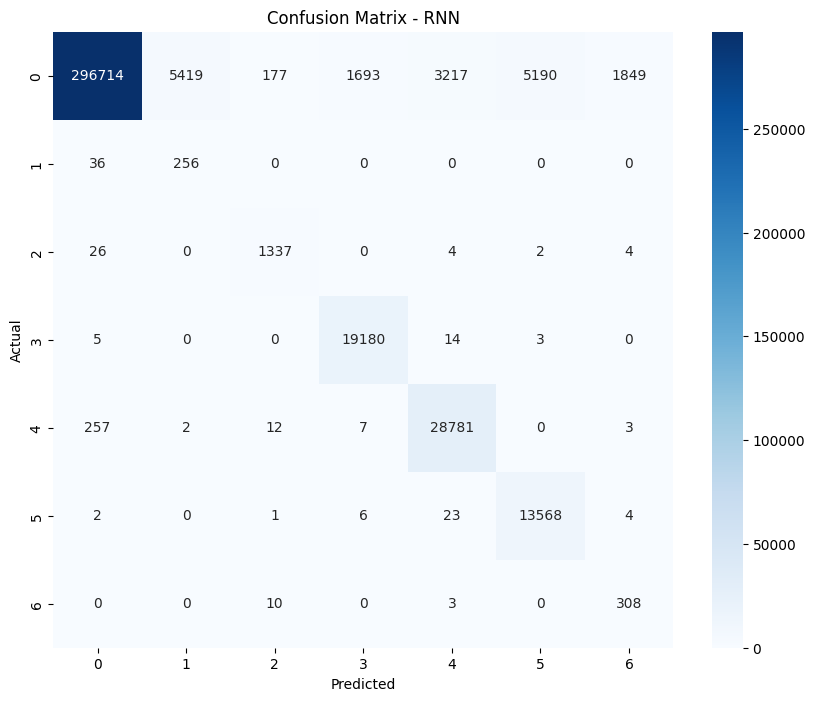

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

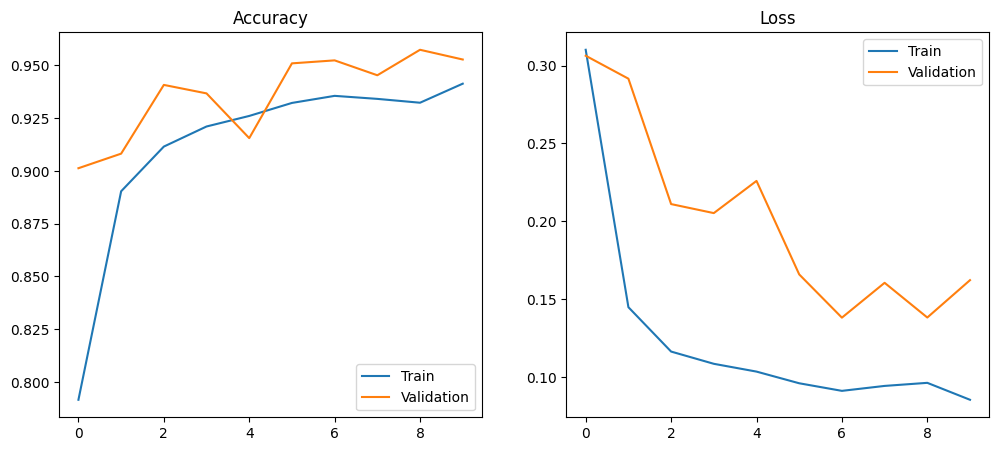

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [17]:
# Save in legacy HDF5 format
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn_model_fixed.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\rnn_model_fixed.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.
